# Phase 2 → Lesson 5: Model Evaluation & Improvement

 Short Theory — Why This Matters?  

Building a model is easy. But how do you know if it's truly good and not just getting lucky on your small test set? And when it's bad — how do you improve it?

Definition: A diagnostic table showing exactly where a classification model gets confused.

Why Accuracy Fails: Accuracy can hide poor performance on minority/critical classes (e.g., predicting everyone passes, missing the failures).

This lesson gives you the tools every real ML engineer uses daily.

## Concept 1 — Confusion Matrix
For classification models, accuracy alone isn't enough. A confusion matrix shows exactly where your model is getting confused:
```
                  Predicted NO  |   Predicted YES
Actual NO    →   True Negative  |  False Positive
Actual YES   →   False Negative |  True Positive

1. True Negative (TN) — correct decision ✅ means: Student Fail (Actual NO) tha,  model  predict  Fail (Predicted NO) .

result: Model correct.

True Positive (TP) — correct decision ✅ means: Student  Pass (Actual YES)  tha, model   predict  Pass (Predicted YES) hoga.

result: Model correct.

3. False Positive (FP) — wrong Prediction  ❌ means: Student  Fail (Actual NO)  tha, lekin model  khushfehmi mein predict kar diya  Pass (Predicted YES) ho jayega

result: "False Alarm"  model wrong

4. False Negative (FN) — wrong Prediction  ❌ means: Student   Pass (Actual YES) ,but model  predict Fail (Predicted NO).

result :  (Missed Opportunity).
```
confusion_matrix(actual, predicted) → 2x2 matrix

ConfusionMatrixDisplay → visual version with colors

cmap='Blues' → blue color scheme

***output be like of below code:***
```
[[3, 1],    → 3 correct NO, 1 wrong (said YES but was NO)
 [1, 5]]    → 1 wrong (said NO but was YES), 5 correct YES
```

[[3 1]
 [1 5]]


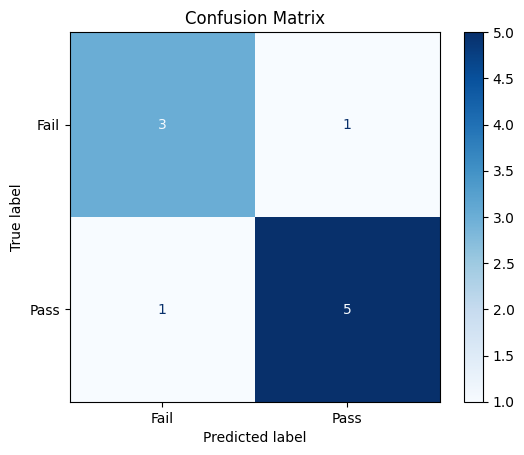

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

y_test = [0, 1, 1, 0, 1, 1, 0, 0, 1, 1] # actual y values of data
y_pred = [0, 1, 0, 0, 1, 1, 1, 0, 1, 1] # predicted values of data
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visual display
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Fail', 'Pass'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()



## Concept 2 — Cross Validation
Splitting data once into 80/20 can be lucky or unlucky depending on which rows end up in test set. Cross Validation solves this:

The Core Problem: A single 80/20 train/test split introduces a Luck Factor (testing on too easy or too hard data rows).The CV Solution: Eliminates luck by splitting the entire dataset into \(K\) equal parts (folds) and rotating the test set.

The Process (e.g., 5-Fold):Model runs 5 distinct rounds.Each individual fold gets a turn to act as the TEST set while the remaining 4 act as the train set.

The Final Metric: Average Score across all 5 iterations \(\rightarrow \) Gives the most honest, stable, and unbiased model performance metric.
```
Split data into 5 equal parts (folds):

Fold 1: [TEST] [train] [train] [train] [train]
Fold 2: [train] [TEST] [train] [train] [train]
Fold 3: [train] [train] [TEST] [train] [train]
Fold 4: [train] [train] [train] [TEST] [train]
Fold 5: [train] [train] [train] [train] [TEST]

Final score = average of all 5 test scores
```
cross_val_score(model, X, y, cv=5) → trains and tests 5 times automatically

Returns array of 5 scores


scores.std() → consistency — low std = stable model


 Always use cross validation for final model evaluation in real projects. Single train/test split is too unreliable.
 ```
 Dataset ──> Split ──> [ Train Set (80%) ] ───> Multi-Fold Cross Validation (Tune & Select Model)
                    └──> [ Test Set (20%) ]  ───> Final Exam (Run only ONCE at the very end)

 ```
 ### 🧠 The Ultimate Validation & Tuning Concept
* **The Purpose of CV + Tuning:** It is purely a **decision-making and diagnostic tool** to identify the best configuration (hyperparameters) for the model.
* **Model State:** Running `cross_val_score` or tuning setups does *not* permanently train or save weights into the final model instance.it means it not gonna effect our normal model training flow.
* **The Standard Action:** Once the best hyperparameters are decided via CV, we manually initialize the final model with those optimal settings and call `model.fit(X_train, y_train)` to perform the actual training.


In [5]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
data = {
    'StudyHours': [1,2,3,4,5,6,7,8,9,10],
    'Passed':     [0,0,0,0,1,1,1,1,1,1]}

df = pd.DataFrame(data)
X = df[['StudyHours']]
y = df['Passed']

model = RandomForestClassifier(n_estimators=100, random_state=42)

scores = cross_val_score(model, X, y, cv=5)
print(f'CV Scores:  {scores}')
print(f'Mean Score: {scores.mean():.2f}')
print(f'Std Dev:    {scores.std():.2f}')

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


CV Scores:  [0.5 1.  1.  1.  1. ]
Mean Score: 0.90
Std Dev:    0.20


## Concept 3 — Hyperparameter Tuning

Every model has settings you can adjust — these are called hyperparameters. Finding the best combination is called tuning.

***Definition:*** Adjusting the external settings (hyperparameters) of a model before training to maximize its performance.

***Analogy:*** Like tuning the sensitivity or graphics settings in a video game for optimal gameplay.

***Examples*** (Random Forest): n_estimators (number of trees), max_depth (how deep a tree grows).

***Goal:*** Finding the perfect combination of settings that gives the highest validation accuracy and prevents overfitting.

param_grid → dictionary of parameters and values to try
GridSearchCV → tries every combination (4×3=12 combinations here)
cv=5 → uses cross validation for each combination
best_params_ → the winning combination
best_estimator_ → ready-to-use best model


🔑 GridSearchCV is trying 12 models × 5 folds = 60 training runs automatically. This is how professionals find optimal models. and also give training data rather than whole

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define parameters to try
param_grid = {
    'max_depth':        [2, 3, 4, 5],
    'min_samples_split': [2, 3, 4]}

model = DecisionTreeClassifier(random_state=42)

# Try all combinations automatically
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X, y)

print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best Score:      {grid_search.best_score_:.2f}')

# Use best model
# best_model = grid_search.best_estimator_ not in use till

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'max_depth': 2, 'min_samples_split': 2}
Best Score:      0.90


 ## Concept 4 — Overfitting vs Underfitting
 ***Underfitting:***

 Model is too simple to learn the underlying patterns.

 **Symptom:** Bad performance on both Training and Testing data.

 ***Overfitting:***

 Model memorizes (rattas) the training data, including the noise and errors.

 **Symptom:** Perfect performance on Training data, but terrible performance on Unseen Testing data.The

  ***Goal:***
  
   Find the "Sweet Spot" where the model generalizes well to new, unseen data.

***Reading the output:***

Depth 1 → Train: 0.75  Test: 0.50  ← Underfitting (too simple)
Depth 3 → Train: 0.90  Test: 0.90  ← Just right ✅
Depth 5 → Train: 1.00  Test: 0.50  ← Overfitting (memorized!)

Perfect 1.00 Across All Depths: Occurs when the synthetic dataset is too simple, perfectly separable, or linearly split by a single rule.

Why it's a Red Flag in Real Data: In real-world projects, achieving 100% accuracy at Depth 1 is impossible due to noise. It usually indicates Data Leakage or a faulty data split.

Conclusion: Always test models on noisy, real-world data to truly evaluate Overfitting vs Underfitting.

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

for depth in [1, 2, 3, 4, 5]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score  = model.score(X_test,  y_test)

    print(f'Depth {depth} → Train: {train_score:.2f}  Test: {test_score:.2f}')

Depth 1 → Train: 1.00  Test: 1.00
Depth 2 → Train: 1.00  Test: 1.00
Depth 3 → Train: 1.00  Test: 1.00
Depth 4 → Train: 1.00  Test: 1.00
Depth 5 → Train: 1.00  Test: 1.00


# Practice —  TASKS TO TRY
Task 1: Build a Decision Tree, print and visualize the confusion matrix.

Task 2: Run 5-fold cross validation on a Random Forest. Print mean score and std.

Task 3: Use GridSearchCV to find best max_depth and min_samples_split for Decision Tree.

Task 4 : Loop through depths 1-5, print train vs test score for each. Which depth is best?

Task 5 (thinking): Your model has train accuracy=0.99 and test accuracy=0.60. What is this called and how would you fix it?


--- Dataset Summary ---
             Age        Salary  Bought_Car
count  12.000000     12.000000   12.000000
mean   43.916667  47083.333333    0.666667
std    13.846288  13324.334084    0.492366
min    22.000000  25000.000000    0.000000
25%    33.500000  38000.000000    0.000000
50%    46.500000  49500.000000    1.000000
75%    55.250000  58500.000000    1.000000
max    62.000000  65000.000000    1.000000

=== TASK 1: Decision Tree Baseline ===
Train CV Mean Score: 1.00
Actual Labels:    [1, 0, 0]
Predicted Labels: [np.int64(1), np.int64(0), np.int64(0)]
Test Accuracy:    1.00


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


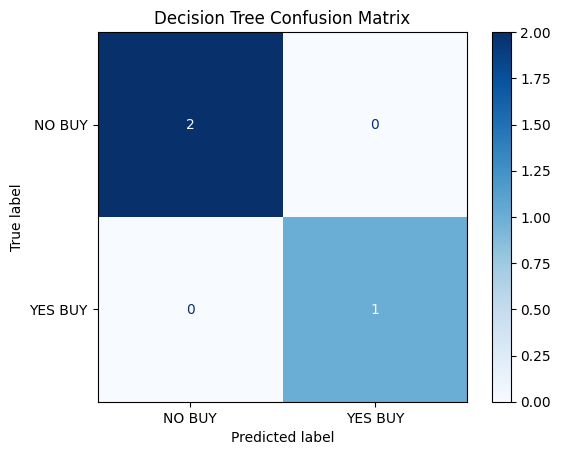


=== TASK 2: Random Forest Baseline ===
Random Forest Accuracy: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


=== TASK 3: Hyperparameter Tuning via GridSearchCV ===


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


DT Best Params: {'max_depth': 2, 'min_samples_split': 2}
DT Best CV Score: 1.00


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


RF Best Params: {'max_depth': 2, 'min_samples_split': 2}
RF Best CV Score: 1.00

--- Depth Analysis Experiment ---
Depth 1 → Train Acc: 1.00 | Test Acc: 1.00
Depth 2 → Train Acc: 1.00 | Test Acc: 1.00
Depth 3 → Train Acc: 1.00 | Test Acc: 1.00
Depth 4 → Train Acc: 1.00 | Test Acc: 1.00
Depth 5 → Train Acc: 1.00 | Test Acc: 1.00


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# =====================================================================
# 📦 STEP 1: DATA PREPARATION
# =====================================================================
data = {
    'Age':        [22, 25, 47, 52, 46, 56, 55, 60, 62, 35, 38, 29],
    'Salary':     [25000, 30000, 52000, 48000, 51000, 60000,
                   58000, 62000, 65000, 40000, 42000, 32000],
    'Bought_Car': [0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0]}

df = pd.DataFrame(data)
X = df[['Age', 'Salary']]
y = df['Bought_Car']

print("--- Dataset Summary ---")
print(df.describe())

# Split the data (80% Train, 20% Test)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =====================================================================
# 🌲 TASK 1: DECISION TREE BASELINE & EVALUATION
# =====================================================================
print("\n=== TASK 1: Decision Tree Baseline ===")
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)

# Cross-Validation on training data to check stability
dt_cv_scores = cross_val_score(dt_model, x_train, y_train, cv=3) # cv=3 because data is small
print(f'Train CV Mean Score: {dt_cv_scores.mean():.2f}')

# Train and predict on test set
dt_model.fit(x_train, y_train)
dt_pred = dt_model.fit(x_train, y_train).predict(x_test)
print(f'Actual Labels:    {list(y_test)}')
print(f'Predicted Labels: {list(dt_pred)}')
print(f'Test Accuracy:    {accuracy_score(y_test, dt_pred):.2f}')

# Plot Confusion Matrix
cm = confusion_matrix(y_test, dt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NO BUY', 'YES BUY'])
disp.plot(cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.show()

# =====================================================================
# 🌳 TASK 2: RANDOM FOREST BASELINE
# =====================================================================
print("\n=== TASK 2: Random Forest Baseline ===")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)

print(f'Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.2f}')
print(classification_report(y_test, rf_pred, zero_division=0))

# =====================================================================
# ⚙️ TASK 3: HYPERPARAMETER TUNING FOR BOTH MODELS
# =====================================================================
print("\n=== TASK 3: Hyperparameter Tuning via GridSearchCV ===")

# Parameter grid definition
param_grid = {
    'max_depth':        [2, 3, 4, 5],
    'min_samples_split': [2, 3, 4]}

# A) Tuning Decision Tree
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=3, scoring='accuracy')
dt_grid.fit(x_train, y_train) # Fixed: Using x_train, y_train
print(f'DT Best Params: {dt_grid.best_params_}')
print(f'DT Best CV Score: {dt_grid.best_score_:.2f}')

# B) Tuning Random Forest
rf_grid = GridSearchCV(RandomForestClassifier(n_estimators=100, random_state=42), param_grid, cv=3, scoring='accuracy')
rf_grid.fit(x_train, y_train) # Fixed: Capital 'X_train' used instead of lowercase 'x'
print(f'RF Best Params: {rf_grid.best_params_}')
print(f'RF Best CV Score: {rf_grid.best_score_:.2f}')

# =====================================================================
# 🔬 EXPERIMENT: DEPTH VS FITTING VISUALIZATION
# =====================================================================
print("\n--- Depth Analysis Experiment ---")
for depth in [1, 2, 3, 4, 5]:
    exp_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    exp_model.fit(x_train, y_train)
    print(f'Depth {depth} → Train Acc: {exp_model.score(x_train, y_train):.2f} | Test Acc: {exp_model.score(x_test, y_test):.2f}')
# Ans of taks 5: i think the model is overfitting and i am gonna fix it by hyperparameter tunning and also increase the amount of data to give more accuracy